# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Grimaldi Damián Daniel
- Alumno 2 : Grando Sofía

## Dataset

- Ubicación: https://drive.google.com/drive/folders/1uz4Rwhidre9K-GnfONCSI7t7-kCRp2XB?usp=sharing

- Fecha de creación: Mayo 2026.

- Total de clases (personas): 14.

- Total de imágenes: 491.

- Formato de archivos: .jpg, .jpeg, .png, etc.

### 1. Fuente de las imagenes: 
- **Privada:** imágenes provenientes de la galería de los integrantes del grupo (familia y amigos).

- **Pública:** imágenes de figuras públicas obtenidas de internet para aumentar la diversidad de rasgos. 

### 2. Balance de clases:
|indice|nombre|tipo|cant. de fotos|
|------|------|------|------|
|0|Amanda|amigo|37|
|1|Angel|amigo|30|
|2|Cesar|familia|35|
|3|Damian|amigo|33|
|4|Deborah|amigo|34|
|5|Facundo|amigo|35|
|6|Harry Styles|famoso|35|
|7|Louis Tomlinson|famoso|36|
|8|Luisina|amigo|36|
|9|Marta|familia|39|
|10|Nicolas|amigo|35|
|11|Sofia|amigo|35|
|12|Sol|amigo|35|
|13|Taylor Swift|famoso|36|

El dataset es balanceado, con un promedio de 35 imagenes por clase. La diferencia entre la clase con mayor cantidad de imagenes (Marta, 39) y la menor (Ángel, 30) es baja.

### 3. Variaciones:
Para asegurarnos que el modelo reconozca a personas en situaciones del mundo real se seleccionaron imagenes con diferentes variaciones de iluminacion, poses, expresiones, accesorios y looks (cambios de cabello y maquillaje). 

### 4. Reglas de filtrado y calidad:
No se aceptaron todas las imagenes extraidas de la galeria. Se aplicó un filtrado manual para eliminar todas aquellas con baja resolucion o nitidez y se recortaron algunas para asegurar que solo exista un rostro visible. 
Para aquellas clases con menor volumen de datos, se aplicaron técnicas de *Data Augmentation*, como rotaciones leves, espejado horizontal y ajustes de brillo y contraste. Esto permitió expandir el dataset y lograr el balance.

---

## primer prueba
### MTCNN

TODO utiliza esta notebook para documentar, entrenar y probar el modelo.

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
def carga_dataset(dataset_path: str) -> dict:
    """
    Carga imágenes del dataset y las convierte
    todas a formato RGB consistente.
    """

    data = {}

    for persona in os.listdir(dataset_path):

        carpeta = os.path.join(dataset_path, persona)

        if not os.path.isdir(carpeta):
            continue

        data[persona] = []

        for archivo in os.listdir(carpeta):

            img_path = os.path.join(carpeta, archivo)

            try:
                img = Image.open(img_path).convert("RGB")

                data[persona].append(img)

            except Exception as e:
                print(f"Error cargando {img_path}: {e}")
                continue

    return data

Cargamos las imagenes con el mismo tipo de formato, que en este caso, utilizamos RGB, para que de este modo, MTCNN, tiene que tener un formato consistente para realizar una mejor detección.

In [4]:
personas_dataset = carga_dataset("data")

In [5]:
def detection_face(img) -> list[tuple[int,int,int,int]] | None:
    '''
    A partir de una imagen de entrada, con MTCNN, se aplica para obtener todos los tipos de posibles rotos
    con un umbral de 0,9, se asegura que realmente sea un rostro y no otra cosa y devuelve una lista de tupla 
    con los valores del bounding box.
    Args:
        img : imagen de entrada 
    Returns:
        
    '''
    try:
        from facenet_pytorch import MTCNN

        faces = []

        detector = MTCNN(image_size=112, margin=0, keep_all=True)
        boxes, probs = detector.detect(img)
        if boxes is None:
            return None

        print(f"Detected {len(boxes)} faces")
        for i, (box, prob) in enumerate(zip(boxes, probs)):
            print(f"  Face {i+1}: box={box.astype(int)}, confidence={prob:.3f}")
            
            if prob < 0.90: # se usa un umbral menor a uno para 
                print(f"    Skipping face {i+1} due to low confidence")
                continue
            x1, y1, x2, y2 = box.astype(int)
            face = (x1, y1, x2, y2)
            faces.append(face)
        return faces

    except ImportError:
        # Fallback: just resize without alignment (for demo)
        print("No MTCNN")
        return [img]
    except Exception as e:
        print(f"Error: {e}")
        return [img]

Utilizamos el modelo MTCNN, ya que a la hora de realizar la alineación facial, es más facil realizarlo. Útilizamos un umbral de 0,9 para determinar que realmente sea una cara, ya que puede darnos falsos positivos, y queremos que realmente sean rostros.

In [6]:
rostro = detection_face(personas_dataset['Damian'][1])

KeyError: 'Damian'

In [7]:
dic = {2: 2}
dic.items

<function dict.items>

In [8]:
dict_personas = {}
for personas, imagenes in personas_dataset.items():
    dict_personas[personas] = []
    for img in personas:
        dict_personas[personas].append([img,detection_face(img)])

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img = personas_dataset['Damian'][0]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()

KeyError: 'Damian'

In [10]:
img = personas_dataset['Damian'][1]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()

KeyError: 'Damian'

Detected 2 faces
  Face 1: box=[ 298  535  713 1017], confidence=1.000
  Face 2: box=[ 331  979  419 1071], confidence=0.741
    Skipping face 2 due to low confidence


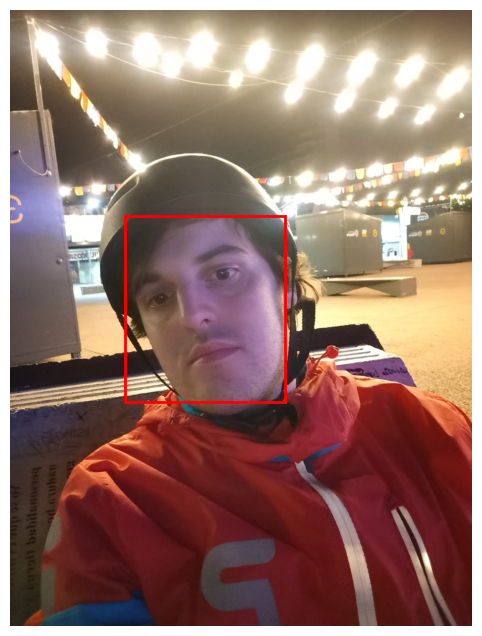

In [ ]:
img = personas_dataset['Damian'][2]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()

# Segunda prueba
### InsightFace

### enlace al comprimido : https://drive.google.com/file/d/1xsbw1IwQCJmYdRSlStWViet_Q7IZqzS_/view?usp=sharing

In [15]:
import torch 
import insightface
from insightface.app import FaceAnalysis
import cv2
import numpy as np        
from PIL import Image    
import json              
from pathlib import Path 
import os

Tomamos de la clase una funcion (*align_face_retinaface*) que usa InsightFace para hacer face analysis de una imagen y devolver datos importantes (embedding, keypoints, bouding box, score y un recorte de la cara en la imagen).

In [ ]:
app = FaceAnalysis(providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

def align_face_retinaface(img) -> list[dict[str, any]] | None:

    cv2_img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    faces = app.get(cv2_img) # analiza la imagen 
                             # guarda los datos de las caras encontradas

    results = []

    for face in faces:

        results.append({
            "embedding": face.embedding,
            "bbox": face.bbox,
            "kps": face.kps,
            "det_score": face.det_score,
            "image": img.crop(face.bbox)
        })
    return results

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Usuario 11/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Usuario 11/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Usuario 11/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Usuario 11/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Usuario 11/.insightface\models\buffalo_l\w600k_r50.onnx recognition [

Se definen las rutas al archivo de entrada formado por las carpetas con las fotos de las personas y al archivo de salida donde se van a guardar los datos sobre estas. 

In [18]:
# Rutas
DATASET_PATH = "../tuia-face-recognition-app/data/Dataset"
OUTPUT_JSON = "../tuia-face-recognition-app/src/data/embeddings.json"

Recorremos de a una las imagenes, pasando por todos los directorios y escribimos el archivo de salida con los datos que se piden en la consigna. El resultado es una lista de diccionarios:
```json
[
    {
        "id_imagen": "nombre de la imagen",
        "embeddings": [0.12, -0.45, 0.88], 
        "path": "ruta/relativa/a/la/imagen.jpg",
        "etiqueta": "nombre de la persona",
        "metadata": {
            "det_score": 0.99,
            "metodo": "RetinaFace"
        }
    }
]
```

In [21]:
# Lista final para la base vectorial
base_vectorial = [] 

print("Iniciando el proceso...")

# Listamos las carpetas (cada una es una persona)
personas = [] #nombres de las carpetas

# Guardamos los nombres de las carpetas
for d in os.listdir(DATASET_PATH):
    ruta_completa = os.path.join(DATASET_PATH, d)
    
    # si es el nombre de un directorio lo agregamos a la lista
    if os.path.isdir(ruta_completa):
        personas.append(d)


for nombre_persona in personas:
    ruta_persona = os.path.join(DATASET_PATH, nombre_persona)
    print(f"\nProcesando a: {nombre_persona}")
    
    # lista de fotos
    fotos = [f for f in os.listdir(ruta_persona) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for nombre_archivo in fotos:
        ruta_completa = os.path.join(ruta_persona, nombre_archivo)
        
        try:
            # Abrimos la imagen
            img_pil = Image.open(ruta_completa).convert('RGB')
            resultados = align_face_retinaface(img_pil)
            
            # Filtrado de calidad
            if resultados and len(resultados) == 1:
                rostro = resultados[0]
                
                # Filtrado de baja fiabilidad
                if rostro['det_score'] > 0.6:
                
                    nuevo_registro = {
                        "id_imagen": nombre_archivo, 
                        "embedding": rostro['embedding'].tolist(),
                        "path": f"data/dataset/{nombre_persona}/{nombre_archivo}",
                        "etiqueta": nombre_persona,
                        "metadata": {
                            "det_score": float(rostro['det_score']),
                            "metodo": "RetinaFace"
                        }
                    }
                    base_vectorial.append(nuevo_registro)
                else:
                    print(f"{nombre_archivo} omitida: Confianza baja ({rostro['det_score']:.2f})")
            elif resultados and len(resultados) > 1:
                print(f"{nombre_archivo} omitida: Múltiples rostros detectados.")
            else:
                print(f"{nombre_archivo} omitida: No se detectó rostro.")
                
        except Exception as e:
            print(f"Error en {nombre_archivo}: {e}")

# Guardamos los resultados en el archivo JSON definitivo
with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(base_vectorial, f, ensure_ascii=False, indent=4)

print("-" * 30)
print(f"¡Proceso finalizado con éxito!")
print(f"Total de registros en base vectorial: {len(base_vectorial)}")
print(f"Archivo guardado en: {OUTPUT_JSON}")

Iniciando el proceso...

Procesando a: Amanda
amanda19.jpg omitida: Confianza baja (0.58)
amanda26.jpg omitida: No se detectó rostro.

Procesando a: Angel
angel13.jpg omitida: Confianza baja (0.58)
angel17.jpeg omitida: Múltiples rostros detectados.
angel23.jpeg omitida: Múltiples rostros detectados.
angel3.jpeg omitida: No se detectó rostro.

Procesando a: Cesar
cesar14.jpeg omitida: Múltiples rostros detectados.
cesar16.jpeg omitida: Múltiples rostros detectados.
cesar19.jpeg omitida: Múltiples rostros detectados.
cesar29.jpeg omitida: Múltiples rostros detectados.
cesar3.jpg omitida: Múltiples rostros detectados.
cesar7.jpeg omitida: Múltiples rostros detectados.

Procesando a: Damian

Procesando a: Deborah
debora11.jpg omitida: Múltiples rostros detectados.
debora33.jpeg omitida: Múltiples rostros detectados.

Procesando a: Facundo
facundo19.jpg omitida: No se detectó rostro.
facundo20.jpg omitida: No se detectó rostro.
facundo31.jpg omitida: Múltiples rostros detectados.

Procesan

### RESULTADO

A pesar de que el proceso de recoleccion de datos dejo fuera algunas de las imagenes del dataset original para evitar ruido aun contamos con los datos de 451/491 imagenes. Esto es suficiente para garantizar una buena representación de cada una de las 14 clases.

La exclusión de estas muestras no representa una perdida significativa, sino una necesaria para descartar aquellas que podian generar ruido o falsos positivos.

Es un comportamiento esperable de *RetinaFace* que es un modelo configurado para tener alta precisión. 

**Estadísticas finales:**
* Imágenes totales: 491
* Embeddings generados: 451

# Conclusión